# <h1 align="center">LegalMind — EDA</h1>

**Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from collections import Counter

/Users/sawadee/global-venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading dataset**

In [2]:
ds = load_dataset("coastalcph/lex_glue", "ecthr_a")

**Dataset Structure**

In [3]:
print("Structure of ds:", ds)
print(ds['train'].features)

Structure of ds: DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
})
{'text': List(Value('string')), 'labels': List(ClassLabel(names=['2', '3', '5', '6', '8', '9', '10', '11', '14', 'P1-1']))}


- The dataset has 9,000 training cases, 1,000 test cases, and 1,000 validation cases, where each case is a list of text paragraphs labeled with which of 10 possible ECHR articles (if any) were violated.

**Article Label Mapping**

In [4]:
articles = ds['train'].features['labels'].feature.names

**Article Reference**

- For reference — mapping of article codes to their titles below


| Code | Article |
|------|---------|
| 2 | Right to life |
| 3 | Prohibition of torture |
| 5 | Right to liberty |
| 6 | Right to fair trial |
| 8 | Private/family life |
| 9 | Freedom of thought |
| 10 | Freedom of expression |
| 11 | Freedom of assembly |
| 14 | Prohibition of discrimination |
| P1-1 | Protection of property |

**One record check**

In [5]:
print(ds['train'][0])

{'text': ['11.  At the beginning of the events relevant to the application, K. had a daughter, P., and a son, M., born in 1986 and 1988 respectively. P.’s father is X and M.’s father is V. From March to May 1989 K. was voluntarily hospitalised for about three months, having been diagnosed as suffering from schizophrenia. From August to November 1989 and from December 1989 to March 1990, she was again hospitalised for periods of about three months on account of this illness. In 1991 she was hospitalised for less than a week, diagnosed as suffering from an atypical and undefinable psychosis. It appears that social welfare and health authorities have been in contact with the family since 1989.', '12.  The applicants initially cohabited from the summer of 1991 to July 1993. In 1991 both P. and M. were living with them. From 1991 to 1993 K. and X were involved in a custody and access dispute concerning P. In May 1992 a residence order was made transferring custody of P. to X.', '13.  K. was

- This first case is quite long (93 paragraphs) and involves a family/child-welfare dispute in Finland, **Article 8** (right to private and family life) — makes sense given the facts are all about custody, access restrictions, and public care of children.

**Text Length Analysis**

In [6]:
lengths = [len(case) for case in ds['train']['text']]
print(f"\n=== CASE LENGTH ===")
print(f"Mean: {np.mean(lengths):.1f} paragraphs")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")


=== CASE LENGTH ===
Mean: 23.7 paragraphs
Min: 1, Max: 558


- The average case is about 24 paragraphs, but the range is huge (from 1 to 558) - dataset has high variance in case length.

**Text Length Analysis - Visualization**

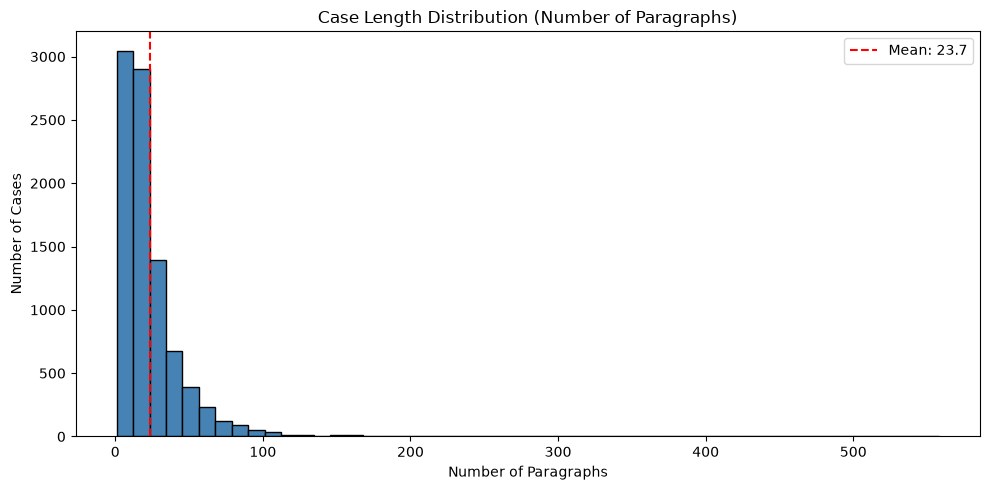

In [7]:
lengths = [len(case) for case in ds['train']['text']]

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black')
plt.title('Case Length Distribution (Number of Paragraphs)')
plt.xlabel('Number of Paragraphs')
plt.ylabel('Number of Cases')
plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

**Text Length Analysis — Characters/Tokens**

In [8]:
char_lengths = [len(" ".join(case)) for case in ds['train']['text']]

print(f"Mean: {np.mean(char_lengths):.0f} chars")
print(f"Min: {min(char_lengths)}, Max: {max(char_lengths)}")
print(f"Approx tokens (chars/4): mean={np.mean(char_lengths)/4:.0f}, max={max(char_lengths)/4:.0f}")

Mean: 9798 chars
Min: 390, Max: 209861
Approx tokens (chars/4): mean=2450, max=52465


- Mean case: ~2,450 tokens; max: ~52,500 tokens (21x mean) — chunking should be based on character/token count, because max will be too big for one prompt

**Article Distribution**

In [9]:
all_labels = [l for case in ds['train']['labels'] for l in case]
counter = Counter(all_labels)
print("=== ARTICLE DISTRIBUTION ===")
for idx, count in sorted(counter.items()):
    print(f"Article {articles[idx]}: {count} cases")

=== ARTICLE DISTRIBUTION ===
Article 2: 505 cases
Article 3: 1349 cases
Article 5: 1368 cases
Article 6: 4704 cases
Article 8: 710 cases
Article 9: 41 cases
Article 10: 291 cases
Article 11: 110 cases
Article 14: 141 cases
Article P1-1: 1421 cases


- Article 6 dominates (4,704 cases), Article 9 is almost absent (41 cases) — a ~115x imbalance. Per-article metrics are needed to check if the Judge will genuinely reason or just default to Article 6.

**Article Distribution - Visualization**

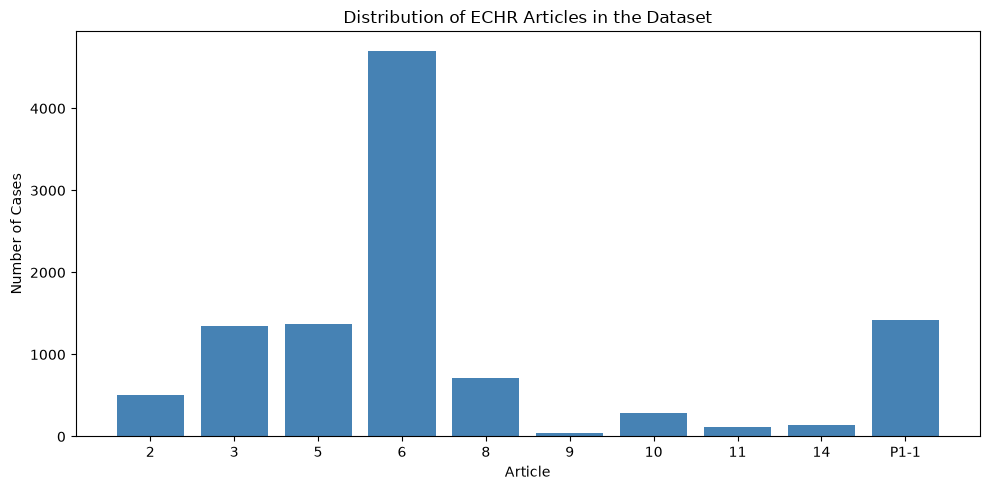

In [10]:

all_labels = [l for case in ds['train']['labels'] for l in case]
counter = Counter(all_labels)
counts = [counter[i] for i in range(len(articles))]

plt.figure(figsize=(10,5))
plt.bar(articles, counts, color='steelblue')
plt.title('Distribution of ECHR Articles in the Dataset')
plt.xlabel('Article')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()

**Multi-label Analysis**

In [11]:
multi = [len(l) for l in ds['train']['labels']]
print(f"\n=== NUMBER OF VIOLATIONS PER CASE ===")
print(f"Mean: {np.mean(multi):.1f}")
print(f"Only 1 violation: {sum(1 for x in multi if x==1)}")
print(f"2+ violations: {sum(1 for x in multi if x>1)}")


=== NUMBER OF VIOLATIONS PER CASE ===
Mean: 1.2
Only 1 violation: 5924
2+ violations: 2162


- Most cases have 1 violation (5,924), but some (2,162) have 2+.
- Multi-label handling is needed — the Judge must be able to output multiple articles, not just the single best guess.

**Violation vs No-Violation Baseline**

In [12]:
no_violation = sum(1 for l in ds['train']['labels'] if len(l) == 0)
has_violation = sum(1 for l in ds['train']['labels'] if len(l) > 0)

print(f"No violation: {no_violation} ({no_violation/len(ds['train'])*100:.1f}%)")
print(f"Has violation: {has_violation} ({has_violation/len(ds['train'])*100:.1f}%)")

No violation: 914 (10.2%)
Has violation: 8086 (89.8%)


- Dataset is heavily skewed toward "violation found" (89.8%). Evaluation must check the Judge's no-violation cases specifically (10.2% of data) — a Judge with "violation" would score deceptively well on aggregate accuracy.

**Co-occurrence Analysis**

In [13]:
pairs = Counter()
for labels in ds['train']['labels']:
    if len(labels) > 1:
        for i in range(len(labels)):
            for j in range(i+1, len(labels)):
                pairs[(labels[i], labels[j])] += 1
print("=== TOP CO-OCCURRENCE ===")
for (a,b), count in pairs.most_common(5):
    print(f"Art.{articles[a]} + Art.{articles[b]}: {count}x")


=== TOP CO-OCCURRENCE ===
Art.6 + Art.P1-1: 958x
Art.3 + Art.5: 454x
Art.5 + Art.6: 259x
Art.2 + Art.3: 222x
Art.2 + Art.5: 199x


- Article 6 + P1-1 co-occur far more than any other pair (958x) - This pair deserves closer investigation (e.g., relative to each article's total case count) before building an evaluation rule on it

In [17]:
# how often each article in a pair also shows up with the other, in both directions

for (a, b), c in pairs.most_common(5):
    print(f"{articles[a]}+{articles[b]}: {c}x | ->{articles[b]}: {c/counter[a]:.0%} | ->{articles[a]}: {c/counter[b]:.0%}")

6+P1-1: 958x | ->P1-1: 20% | ->6: 67%
3+5: 454x | ->5: 34% | ->3: 33%
5+6: 259x | ->6: 19% | ->5: 6%
2+3: 222x | ->3: 44% | ->2: 16%
2+5: 199x | ->5: 39% | ->2: 15%


- 4 of 5 pairs have a strong directional link (≥30%+ one way); only Art.5+6 is weak both ways.
- Judge should have  cross-checks for P1-1→6, 2→3, 2→5 (one-directional), and 3↔5 (both directions); and  5+6 can be skipped

**Co-occurance Visualization**

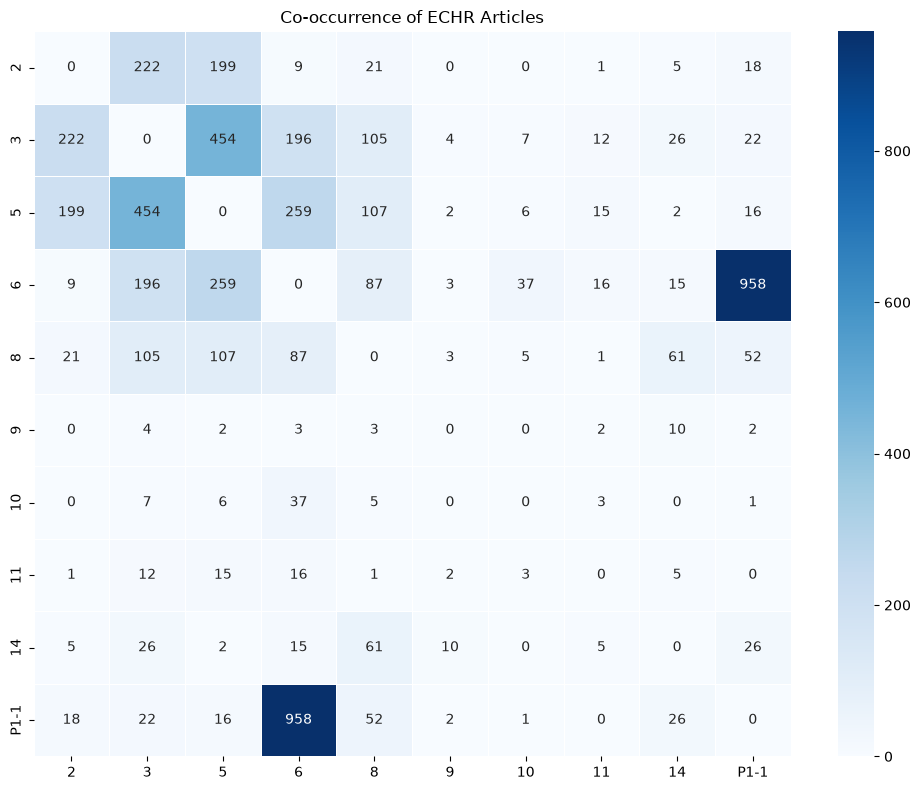

In [ ]:
n = len(articles)
matrix = np.zeros((n, n))

for (a, b), count in pairs.items():
    matrix[a][b] = count
    matrix[b][a] = count

plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    xticklabels=articles,
    yticklabels=articles,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5
)
plt.title('Co-occurrence of ECHR Articles')
plt.tight_layout()
plt.show()

**Outliers**

In [19]:
for p in [75, 90, 95, 99]:
    print(f"{p}th percentile: {np.percentile(lengths, p):.0f} paragraphs")

75th percentile: 29 paragraphs
90th percentile: 48 paragraphs
95th percentile: 63 paragraphs
99th percentile: 105 paragraphs


- 50 ≈ 90th percentile, so it is an reasonable choice for a threshold

In [18]:
lengths = [len(case) for case in ds['train']['text']]
long = sum(1 for l in lengths if l > 50)
print(f"=== LONG CASES (>50 paragraphs) ===")
print(f"{long} cases ({long/len(lengths)*100:.1f}%) require truncation")
short = sum(1 for l in lengths if l < 3)
print(f"\n=== VERY SHORT CASES (<3 paragraphs) ===")
print(f"{short} cases - potentially problematic")

=== LONG CASES (>50 paragraphs) ===
791 cases (8.8%) require truncation

=== VERY SHORT CASES (<3 paragraphs) ===
3 cases - potentially problematic


- 791 cases (8.8%) exceed 50 paragraphs and get truncated; only 3 are extremely short. Truncation is a real but limited concern (~9% of cases)

**Outliers Visualization**

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(lengths, vert=False)
plt.xlabel('Number of paragraphs')
plt.title('Outliers — Case Length (Boxplot)')
plt.tight_layout()
plt.show()

**Truncation Bias Check**

In [20]:
df = pd.DataFrame({'length': lengths, 'labels': ds['train']['labels']})
df['truncated'] = df['length'] > 50
for i, art in enumerate(articles):
    rate_trunc = df[df['truncated']]['labels'].apply(lambda l: i in l).mean()
    rate_all = df['labels'].apply(lambda l: i in l).mean()
    print(f"{art}: {rate_trunc:.2f} (truncated) vs {rate_all:.2f} (overall)")


2: 0.31 (truncated) vs 0.06 (overall)
3: 0.49 (truncated) vs 0.15 (overall)
5: 0.37 (truncated) vs 0.15 (overall)
6: 0.25 (truncated) vs 0.52 (overall)
8: 0.15 (truncated) vs 0.08 (overall)
9: 0.01 (truncated) vs 0.00 (overall)
10: 0.01 (truncated) vs 0.03 (overall)
11: 0.01 (truncated) vs 0.01 (overall)
14: 0.02 (truncated) vs 0.02 (overall)
P1-1: 0.06 (truncated) vs 0.16 (overall)


- Truncated cases skew heavily toward Article 2, 3, and 5 (life, torture, liberty) — 2.5–5x overrepresented vs their overall rate — while Article 6 and P1-1 are underrepresented among truncated cases. 
- Truncation isn't neutral — it disproportionately cuts evidence from the most severe rights violations (life, torture, detention) - so the optimal strategy is to summarize long cases rather than hard-truncate them.

**Train-Test Distribution Consistency Check + Validation**

In [ ]:
test_lengths = [len(case) for case in ds['test']['text']]
test_labels = [l for case in ds['test']['labels'] for l in case]
test_counter = Counter(test_labels)

val_lengths = [len(case) for case in ds['validation']['text']]
val_labels = [l for case in ds['validation']['labels'] for l in case]
val_counter = Counter(val_labels)

print("=== LENGTH: TRAIN vs VALIDATION vs TEST ===")
print(f"Train mean: {np.mean(lengths):.1f} paragraphs")
print(f"Validation mean: {np.mean(val_lengths):.1f} paragraphs")
print(f"Test mean: {np.mean(test_lengths):.1f} paragraphs")

print("\n=== ARTICLE DISTRIBUTION: TRAIN vs VALIDATION vs TEST ===")
for idx, art in enumerate(articles):
    print(f"Article {art}: train={counter[idx]}, val={val_counter[idx]}, test={test_counter[idx]}")

- Length is consistent across all three splits, and the Article 6 drop matches between validation and test — but Article 8 and Article 10 are notably more common in test than in either train or validation.
- Validation should be used for tuning, but shouldn't be fully trusted as a preview of test performance — Judge accuracy on Article 8/10 specifically should be checked once run on test, since validation doesn't warn about that shift.

**Train-Test Duplicate Check**

In [ ]:
# Exact duplicates

train_texts = set(" ".join(c) for c in ds['train']['text'])
test_texts = [" ".join(c) for c in ds['test']['text']]

exact_dupes = sum(1 for t in test_texts if t in train_texts)
print(f"Exact duplicates: {exact_dupes} / {len(test_texts)}")

In [ ]:
# Near duplicates - checking whether test-ds it shares at least a few exact paragraphs with train-ds

near_dupes = 0
for test_case in ds['test']['text'][:200]:
    test_paragraphs = set(test_case)
    for train_case in ds['train']['text']:
        shared = len(test_paragraphs & set(train_case))
        if shared >= 3:
            near_dupes += 1
            break

print(f"Near duplicates (200-sample from test): {near_dupes} / 200")

- No exact duplicates (0/1000) and no near-duplicates in a 200-case sample of test were found.